# LLM-assisted pharmacovigilance pipeline

### prioritizing potentially unlabeled adverse drug reactions from FAERS

This notebook is the full report of the project — introduction, statistical modeling,
LLM use, and scoring — for the hackathon of the **2nd AI Workshop**, New York City.

| Section | Subtitle | Contents |
|---|---|---|
| 1 | Introduction | (1) Project goal, (2) what FAERS is, and (3) why an LLM |
| 2 | Data (Stage 0) | (1) What is actually in a FAERS report, and (2) the analyzed structure |
| 3 | MGPS & EBGM (Stage 1) | Statistical modeling of drug–PT disproportionality |
| 4 | PT triage (Stage 2) | FAERS records *adverse events*; we want *adverse reactions* — so which PTs are plausable drug reaction? |
| 5 | Label comparison (Stage 3) | Matching each significant drug–PT pair against that drug's actual FDA label |
| 6 | Scoring (Stage 4) | Prioritizing the remaining PTs per drug across five criteria |
| 7 | Discussion | (1) What the pipeline achieves, (2) what the limitations are |

<br>

> **A note on AI assistance.** The analysis code and the text of this report were drafted with an LLM (Claude Code) working against the actual data and codebase. Every stage was then reviewed, corrected, and edited by hand — the pipeline design, the statistical choices, the prompt engineering, the drug brand curation, and the interpretation of results are mine.



---
## 1. Introduction

### 1.1 The goal

Given the FDA Adverse Event Reporting System (FAERS), produce **for each drug a ranked shortlist of adverse events (AEs) that are (a) statistically disproportionate, (b) adverse drug reaction (ADR), (c) *not already on the drug's FDA label*, and (d) worth investigating further.**

Classical disproportionality analysis answers only (a) — for thousands of pairs. What a reviewer needs is the handful of ADRs that could be a *new* safety signal.

### 1.2 What FAERS is

FAERS is the FDA's **spontaneous adverse-event** reporting database: reports arrive voluntarily from clinicians and patients, and through mandatory manufacturer channels. Three properties dictate what analysis is possible:

- **No denominator.** We never know how many people took the drug and were fine — so no incidence rate, no epidemiological relative risk.
- **No causality.** A report says only "this event happened to someone taking this drug."
- **Heavily confounded.** Multiple drugs per report, comorbidities, and reporting biases.

FAERS therefore cannot tell you a drug *causes* an event — only that the event is reported **disproportionately often** with it. That is a signal to investigate, not a conclusion.

### 1.3 The usual analysis: disproportionality on a 2×2 table

For every (drug, event) pair, collapse the whole database into a contingency table:

|  | **event = PT** | **event ≠ PT** | |
|---|---|---|---|
| **drug = D** | `a` | `b` | a+b |
| **drug ≠ D** | `c` | `d` | c+d |
| | a+c | b+d | N |

Under independence the expected count is `E = (a+b)(a+c)/N`, and `RR = a/E` is the raw signal. Every classical measure — **Proportional Reporting Ratio (PRR)** = `[a/(a+b)] / [c/(c+d)]`, **Reporting Odds Ratio (ROR)** = `(a/b) / (c/d) = ad/bc`, and **EBGM** (Gamma-Poisson Shrinker, DuMouchel 1999; see the [FDA data-mining white paper](https://www.fda.gov/science-research/data-mining/data-mining-fda-white-paper)) — is a function of this table. We use EBGM; see §3.

**Why raw RR/PRR is not enough:** most pairs have tiny counts. A pair seen twice against an expected count of 0.001 has an enormous PRR and means nothing. Empirical Bayes exists to shrink those away.

### 1.4 Where the LLM comes in

Disproportionality is a *statistical* filter. Everything after it has required a human expert reading MedDRA terms and FDA labels — and those are the judgments we hand to a frontier LLM:

| Judgment | Previously | Here |
|---|---|---|
| Is this PT even a clinical *reaction* (vs. a lab name, device complaint, medication error)? | expert triage | **Stage 2**, drug-agnostic categorization of every PT |
| Is it already described on *this drug's* label? | expert reads the SPL | **Stage 3**, hierarchical classification against the openFDA label |
| Is it severe / biologically plausible / literature-supported? | expert intuition | **Stage 4**, embedding-based semantic scoring |

**Models:** `gpt-4.1` (`temperature=0`, for reproducible labels) for Stages 2–3; `text-embedding-3-large` for the Stage 4 semantic axes. Stage 1 stays in R — **the LLM never touches the statistical analysis.**


---
## 2. Dataset (Stage 0) — What is in a FAERS report?

### 2.1 The seven files

Each FAERS quarterly release splits every report across seven tables, joined on `primaryid`. Only three of them carry what the pipeline needs:

| File | Contents | Used here? |
|---|---|---|
| `DEMO` | caseid, `caseversion`, `lit_ref` (literature citation), age, sex, etc. | **yes** |
| `DRUG` | **one row per drug on the report**: `prod_ai` (active ingredient), `role_cod`, dose, etc. | **yes** |
| `REAC` | **one row per reaction**: MedDRA `pt` | **yes** |
| `OUTC` | outcome codes (death, hospitalization, etc.) | no |
| `RPSR` | report source | no |
| `THER` | therapy start/end dates | no |
| `INDI` | indication for use | no |

**Data coverage: 2024Q1 – 2026Q1.**

### 2.2 The unit of analysis: a (drug, PT) pair

A single report lists **one or more drugs (active ingredients)** and **one or more PTs (adverse events)**. The analysis pairs every suspect drug on a report with every reaction on that report. **A pair is counted once per report**, so each cell of the 2×2 table counts *reports*.

### 2.3 MedDRA Preferred Terms (PT)

Reactions are coded as **MedDRA Preferred Terms** — one PT = one coded medical concept. But MedDRA is a *general* medical dictionary, not a list of adverse reactions. Its terms cover:

- signs, symptoms, and diagnoses — *Hepatic failure*, *Seizure*, *Rash*
- investigations (test names and results) — *Blood glucose increased*
- procedures — *Dialysis*
- therapeutic context, product complaints, and administrative terms — *Drug ineffective*, *Off label use*, *Product quality issue*

Separating the terms that could be an adverse reaction from the terms that intrinsically cannot is the entire motivation for Stage 2.

### 2.4 Processing and outputs

`step0_process_data.R` imports the quarterly ZIPs and applies three filters, in order:

1. **Deduplicate case versions.** Keep only the **latest `caseversion` per `caseid`**.
2. **Suspect drugs with a known ingredient.** `role_cod ∈ {PS, SS}` and `prod_ai` not missing.
3. **Cap bulk multi-drug reports.** Reports with **> 10** distinct suspect ingredients are dropped, since the many-to-many join would turn each one into hundreds of spurious drug–AE co-occurrences.

It writes three tables:

- **`drug_reac_pairs.csv`** — one row per (report, drug, PT). The input to the 2×2 counts in Stage 1.
- **`pair_features.csv`** — per (drug, PT): `n_reports` and **`median_suspects`**, the median number of suspect drugs on the reports carrying that pair (it counts the pair's own drug, so the minimum is 1).
- **`pair_litref.csv`** — the **literature citations** attached to the reports carrying each pair.


### Setup

Run this cell first — it holds all imports, the shared plot palette, and the small core tables (`signals`, `pt_types`, `adr_results`) used across the sections below. Large, section-specific files (`drug_reac_pairs`, `ebgm_scores`, `pair_litref`, `scored_adrs`) are loaded locally where they are used.

In [25]:
# ===== Setup -- run first: imports, shared style, core tables =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import config, taxonomy, openfda
import step3_compare_to_label as s3
import step4_score_pts as s4

# shared plot palette (used across every figure below)
BLUE, GREY, INK, MUTED, GRID = "#2a78d6", "#c3c2b7", "#0b0b0b", "#898781", "#e1e0d9"
STATUS_ORDER  = ["NOVEL", "ALREADY_LABELED", "DISEASE_RELATED"]
STATUS_COLORS = {"ALREADY_LABELED": "#2a78d6", "DISEASE_RELATED": "#c3c2b7", "NOVEL": "#eb6834"}

# core tables: small, used across sections -- load once, name distinctly
signals     = pd.read_csv(config.SIGNALS_CSV)
pt_types    = pd.read_csv(config.PT_TYPES_CSV)
adr_results = pd.read_csv(config.ADR_RESULTS_CSV)   # Stage-3 output: drug x PT + status

for _n, _df in [("signals", signals), ("pt_types", pt_types), ("adr_results", adr_results)]:
    print(f"{_n:12} {_df.shape}")

signals      (177823, 10)
pt_types     (9032, 3)
adr_results  (3250, 11)


In [26]:
# ~1 GB: read only the three columns we need, and store the strings as categories
pairs = pd.read_csv(
    config.PROCESSED_DIR / "drug_reac_pairs.csv",
    usecols=["primaryid", "prod_ai", "pt"],
    dtype={"prod_ai": "category", "pt": "category"},
)

# The three count distributions.
# Rows are already distinct (report, drug, PT), so size() == number of reports.
per_pair  = pairs.groupby(["prod_ai", "pt"], observed=True).size()               # cell count  (N)
per_drug  = pairs[["primaryid", "prod_ai"]].drop_duplicates()["prod_ai"].value_counts()  # row margin  (N_v1)
per_pt    = pairs[["primaryid", "pt"]].drop_duplicates()["pt"].value_counts()            # col margin  (N_v2)

print(f"reports (unique primaryid) : {pairs.primaryid.nunique():,}")
print(f"(report, drug, PT) rows    : {len(pairs):,}")
print(f"unique drug-PT pairs       : {len(per_pair):,}")
print(f"unique drugs (prod_ai)     : {len(per_drug):,}")
print(f"unique PTs                 : {len(per_pt):,}")
print()
print("How many reports are there for each drug-PT pair, drug, and PT?")
print(pd.DataFrame({"drug-PT pair": per_pair.describe(), "drug": per_drug.describe(),
                    "PT": per_pt.describe()}).round(1).to_string())

reports (unique primaryid) : 3,146,125
(report, drug, PT) rows    : 14,762,532
unique drug-PT pairs       : 1,617,568
unique drugs (prod_ai)     : 7,655
unique PTs                 : 18,838

How many reports are there for each drug-PT pair, drug, and PT?
       drug-PT pair      drug        PT
count     1617568.0    7655.0   18838.0
mean            9.1     559.9     505.5
std            89.4    3877.9    4038.0
min             1.0       1.0       1.0
25%             1.0       2.0       3.0
50%             2.0       9.0      14.0
75%             5.0     109.0      80.0
max         34903.0  241014.0  226094.0


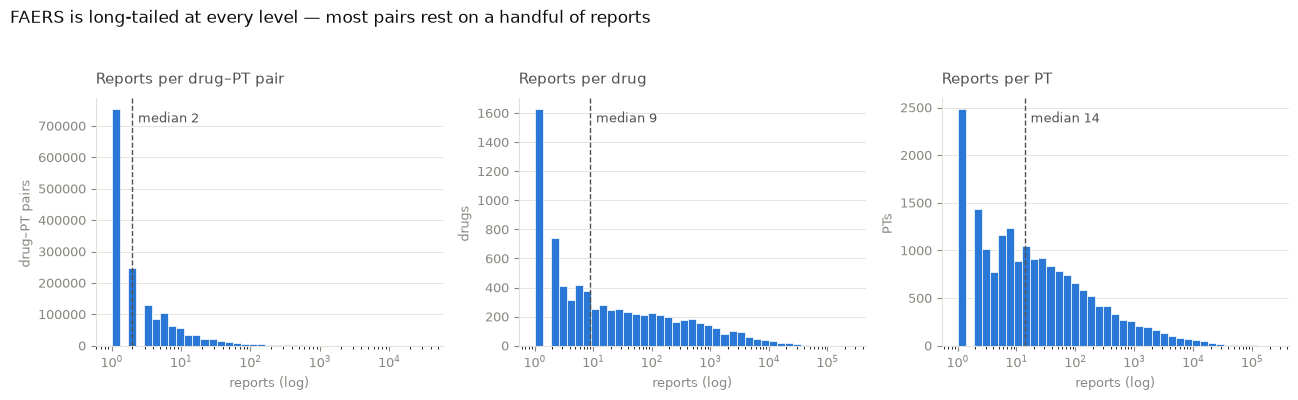

In [27]:
INK = "#52514e"   # this panel uses a slightly lighter ink than the shared palette

panels = [
    (per_pair, "Reports per drug–PT pair", "drug–PT pairs"),
    (per_drug, "Reports per drug",         "drugs"),
    (per_pt,   "Reports per PT",           "PTs"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (s, title, unit) in zip(axes, panels):
    bins = np.logspace(0, np.log10(s.max()), 40)
    ax.hist(s, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.set_xscale("log")
    #ax.set_yscale("log")

    med = s.median()
    ax.axvline(med, color=INK, linewidth=1, linestyle="--")
    ax.annotate(f"median {med:,.0f}", xy=(med, ax.get_ylim()[1]), xytext=(4, -10),
                textcoords="offset points", va="top", fontsize=9, color=INK)

    ax.set_title(title, fontsize=11, color=INK, loc="left", pad=10)
    ax.set_xlabel("reports (log)", fontsize=9, color=MUTED)
    ax.set_ylabel(f"{unit} ", fontsize=9, color=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

fig.suptitle("FAERS is long-tailed at every level — most pairs rest on a handful of reports",
             fontsize=12, color="#0b0b0b", x=0.005, ha="left", y=1.04)
fig.tight_layout()
plt.show()

---
## 3. Stage 1 — Disproportionality (MGPS / EBGM)

### 3.1 The shape of the data dictates the method

The histograms above are extremely right-skewed: the median number of reports is **2** per drug–PT pair, **9** per drug, and **15** per PT. 
So the vast majority of pairs rest on **very few reports** (small `a`), and their margins `(a+b)` and `(a+c)` are small relative to `N` 
— which makes the expected count `E = (a+b)(a+c)/N` tiny, and the relative reporting ratio `RRR = a/E` explode.

What we need is an estimator that **shrinks small-count estimates toward the null — and shrinks them *more* the smaller the count.**

### 3.2 MGPS: the Multi-item Gamma-Poisson Shrinker

This is the model the FDA uses (DuMouchel 1999; see the white paper linked in §1.3). **MGPS** is the model; **EBGM** is the score it produces.

1. **Count.** For every (drug, PT) pair, take the observed count `a` and the expected count `E = (a+b)(a+c)/N` under drug–event independence.
2. **Model.** Treat `a ~ Poisson(λ·E)`, where `λ` is the pair's true reporting ratio. Put a **prior on λ**: a 2-component Gamma mixture (5 parameters — `α₁, β₁, α₂, β₂, P`), which possibly represents a blend of "null" pairs and genuinely elevated ones.
3. **Fit the prior empirically.** Estimate those 5 hyperparameters from the representative pairs by maximum likelihood.
4. **Posterior per pair.** Combine the prior with that pair's `(a, E)` to get a posterior over `λ`:
   - **`EBGM`** — the posterior **geometric mean**. The shrunken point estimate; `EBGM ≈ 1` means "reported as often as expected".
   - **`QUANT_05` (EB05)** — the posterior **5th percentile**. A conservative lower bound: "95% of the posterior probability for λ lies above EB05.."
   - **`QUANT_95` (EB95)** — the 95th percentile.

When a pair has a large count, the data dominate the prior and `EBGM ≈ RRR`. For a small-count pair, the prior dominates and the enormous `RRR` collapses back toward 1.

### 3.3 Signal criterion

A pair is kept as a signal if:

- **`n_reports ≥ 5`**
- **`EB05 > 2`** 

`EB05 > 2` is the conventional threshold. Both criteria are deliberately **lenient here**: the goal of this project is to evaluate the *framework* that follows, so the screen is set to pass enough candidates to exercise Stages 2–4. For real screening, both would be tightened based on the observed distribution and the desired sensitivity.

### 3.4 Processing and outputs

`step1_run_ebgm.R` reads `drug_reac_pairs.csv` and fits the MGPS model via the **openEBGM** package, in four steps:

1. **Count.** `processRaw()` builds the drug × PT contingency counts — `N` (reports carrying both), `E`, `RR`, `PRR`. Every count, including the margins and the total, is a count of **distinct reports** (§2.2).
2. **Squash.** `autoSquash()` collapses ~1.7M pairs into a small set of weighted representative points, so the likelihood is tractable to optimize.
3. **Fit.** `hyperEM()` estimates the 5 hyperparameters by EM on the score equations.
4. **Score.** `ebScores()` computes each pair's posterior → `EBGM`, `QUANT_05`, `QUANT_95`.

It then applies the §3.3 filter, and writes two tables:

- **`signals.csv`** — one row per surviving pair: `prod_ai, pt, n_reports, E, RR, PRR, EBGM, QUANT_05, QUANT_95, median_suspects`. The input to Stages 2–4.
- **`unique_pts.csv`** — every distinct PT appearing in any signal. The input to Stage 2.

<br>

> The huge EBGM's magnitude may reflect the unrestricted comparator: an event specific to one drug class (ovarian hyperstimulation syndrome, post-injection delirium sedation syndrome, scan myocardial perfusion abnormal, etc.) has a near-zero expected count against an all-drug background, so the ratio is enormous. EBGM is therefore used here for **screening and ranking, not as an effect size** — a class-restricted comparator would give more interpretable magnitudes, but would mask class-wide effects.


In [28]:
print(f"pairs passing (n_reports >= 5 & EB05 > 2) : {len(signals):,}")
print(f"unique PTs                                : {signals.pt.nunique():,}")
print(f"unique drugs                              : {signals.prod_ai.nunique():,}")
print(f"survival rate from all drug-PT pairs      : {len(signals) / len(per_pair):.2%}")

signals.head(10)

pairs passing (n_reports >= 5 & EB05 > 2) : 177,823
unique PTs                                : 9,032
unique drugs                              : 3,523
survival rate from all drug-PT pairs      : 10.99%


,prod_ai,pt,n_reports,E,RR,PRR,EBGM,QUANT_05,QUANT_95,median_suspects
0,DOLUTEGRAVIR\LAMIVUDINE\TENOFOVIR DISOPROXIL F...,Congenital umbilical hernia,50,0.002964,16871.11,81756.16,6705.03,5277.88,8421.24,2.0
1,ATOSIBAN,Normal labour,41,0.002118,19353.51,416079.90,6195.20,4752.01,7964.75,7.0
2,CISATRACURIUM BESYLATE,Anaesthetic complication neurological,78,0.008204,9507.12,34223.03,6139.44,5074.98,7373.05,4.0
3,HUMAN CYTOMEGALOVIRUS IMMUNE GLOBULIN,Encephalitis cytomegalovirus,50,0.003913,12776.66,22757.65,5940.78,4676.30,7461.37,9.0
4,NADOFARAGENE FIRADENOVEC-VNCG,Instillation site discharge,106,0.015559,6812.85,187327.01,5280.88,4487.60,6181.05,1.0
5,TECHNETIUM TC-99M SESTAMIBI,Scan myocardial perfusion abnormal,30,0.001221,24566.31,208806.11,5230.57,3828.60,7010.58,2.0
6,PHENAZOPYRIDINE HYDROCHLORIDE,Sulphaemoglobinaemia,27,0.000926,29170.80,56328.89,4958.58,3565.87,6750.12,3.0
7,LUTROPIN ALFA,Ovarian hyperstimulation syndrome,73,0.010780,6771.85,8288.02,4770.11,3917.21,5763.49,4.0
8,TECHNETIUM TC-99M SODIUM PERTECHNETATE,Scan myocardial perfusion abnormal,24,0.000519,46266.54,157303.85,4759.63,3351.54,6599.26,2.0
9,OLANZAPINE PAMOATE,Post-injection delirium sedation syndrome,42,0.004348,9659.16,20333.96,4733.66,3642.91,6067.77,1.0


> The MGPS fit looked unstable: the hyperparameters for the prior did not settle and
> tended toward an uninformative prior, so the empirical-Bayes step may barely shrink
> extreme reporting ratios and EBGM inflated (up to ~6,700). To check this I plotted
> EBGM against log(RR), colored by report count N.

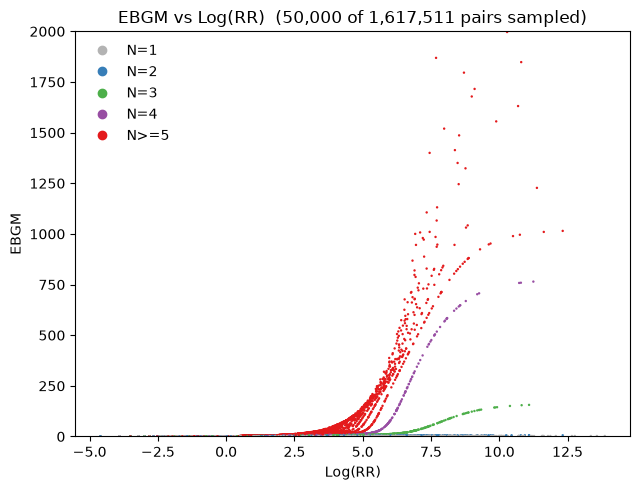

In [29]:
rng = np.random.default_rng(1)                       # set.seed(1)
ebgm_all = pd.read_csv(config.PROCESSED_DIR / "ebgm_scores.csv",
                       usecols=["RR", "EBGM", "n_reports"])
ebgm_all = ebgm_all[ebgm_all["RR"] > 0]              # guard log(RR)

n = min(50_000, len(ebgm_all))
d = ebgm_all.iloc[rng.choice(len(ebgm_all), n, replace=False)].copy()
d["logRR"] = np.log(d["RR"])                         # R log() is natural log

band = d["n_reports"].clip(lower=1, upper=5).astype(int)          # pmin(N, 5)
pal  = ["0.7", "#377eb8", "#4daf4a", "#984ea3", "#e41a1c"]        # N=1..5
colors = [pal[b - 1] for b in band]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(d["logRR"], d["EBGM"], s=3, c=colors, linewidths=0)
ax.set_ylim(0, 2000)                                 # clip: EBGM reaches ~6700
ax.set_xlabel("Log(RR)")
ax.set_ylabel("EBGM")
ax.set_title(f"EBGM vs Log(RR)  ({n:,} of {len(ebgm_all):,} pairs sampled)")

handles = [plt.Line2D([], [], marker="o", ls="", color=pal[i], label=lbl)
           for i, lbl in enumerate(["N=1", "N=2", "N=3", "N=4", "N>=5"])]
ax.legend(handles=handles, loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

---
## 4. Stage 2 — PT triage: is this an adverse *reaction*?

### 4.1 Why this stage exists

Stage 1 hands us a large set of statistically disproportionate (drug, PT) pairs. But a **disproportionate PT is not necessarily an adverse reaction (ADR.)** Some are — *Hepatic failure*, *Seizure* — but MedDRA is a general medical dictionary (§2.3), and reporters populate `REAC` (AEs) with whatever term describes what they saw, including *Drug ineffective* and *Off label use*. The LLM helps us extract the potential ADRs from the AEs.

### 4.2 The formal grounding: AE vs ADR (ICH E2A)

The prompt hands the model the regulatory definitions of AE and ADR from ICH E2A:

- Adverse Event (AE): any untoward medical occurrence in a patient administered a
  medicinal product that does NOT necessarily have a causal relationship with the
  treatment.
- Adverse (Drug) Reaction (ADR): a response to a medicinal product that is noxious
  and unintended, where a causal relationship with the product is at least a
  reasonable possibility.


### 4.3 The taxonomy — 7 categories, 2 kept

Every PT is assigned to exactly one category, judged **drug-agnostically**: by what the term intrinsically *is*, never by whether it is plausible for a particular drug. PTs classified as CLINICAL_EVENT or LAB_OR_INVESTIGATION are then considered plausible drug reactions.

| Category | Kept? | Meaning |
|---|---|---|
| **CLINICAL_EVENT** | ✅ | a genuine sign, symptom, diagnosis, or injury the patient experienced |
| **LAB_OR_INVESTIGATION** | ✅ | a test / imaging / vital-sign name or result |
| LACK_OF_EFFICACY | ❌ | treatment failure, disease progression, condition worsening |
| MEDICATION_ERROR_OR_MISUSE | ❌ | overdose, abuse, off-label use, wrong administration |
| PRODUCT_OR_DEVICE_ISSUE | ❌ | a complaint about the product or device itself |
| ADMINISTRATION_SITE_OR_ROUTE | ❌ | local reaction at the injection / application site |
| NONSPECIFIC_OR_CONTEXT | ❌ | drug-level monitoring, procedures, hospitalisation, administrative terms |

### 4.4 Processing and outputs

`step2_classify_pts.py` reads `unique_pts.csv` and classifies every distinct PT with `gpt-4.1`, one call per batch:

1. **Prompt.** Each batch is sent with the ICH E2A definitions, the goal, and the 7 category definitions and examples (built in `utils/taxonomy.py`).
2. **Parse.** Replies are matched back to the PTs verbatim.
3. **Keep.** `keep = pt_type ∈ {CLINICAL_EVENT, LAB_OR_INVESTIGATION}`.

It writes one table:

- **`pt_types.csv`** — `pt, pt_type, keep`. Consumed by Stage 3 as a drug-agnostic blocklist over `signals.csv`.


In [ ]:
# (1) the actual prompt, on the 50 most common PTs
top = pd.read_csv(config.UNIQUE_PTS_CSV).head(50)       # sorted by n_pairs desc
pts = top.pt.astype(str).tolist()

print(taxonomy.classification_system_prompt())
print("\n" + "=" * 78 + "\n")
print(taxonomy.classification_user_prompt(pts))

You are a senior pharmacovigilance analyst and MedDRA expert.

Definitions:
- Adverse Event (AE): any untoward medical occurrence in a patient administered a
  medicinal product, whether or not causally related to treatment.
- Adverse Drug Reaction (ADR): a noxious and unintended response for which a causal
  relationship with the medicinal product is at least a reasonable possibility.
- MedDRA Preferred Term (PT): one coded medical concept recorded in a FAERS report.

Background:
I have a list of PTs obtained from FAERS reports. FAERS records reported adverse
events, which are not necessarily adverse drug reactions or causally related to a
drug. I want to identify PTs that could plausibly represent an adverse drug reaction
to some drug.

Based on an initial review of the PTs, I created the following categories to help determine which PTs could plausibly represent ADRs.
Use only these categories:

- CLINICAL_EVENT: A genuine sign, symptom, diagnosis, or injury experienced by the patien

In [31]:
# (2) how they came back
top_typed = top.merge(pt_types, on="pt", how="left")[["pt", "n_pairs", "pt_type", "keep"]]
print(f"kept {int(top_typed.keep.sum())}/{len(top_typed)} of the 50 most common PTs\n")
top_typed

kept 34/50 of the 50 most common PTs



,pt,n_pairs,pt_type,keep
0,Drug ineffective,565,LACK_OF_EFFICACY,False
1,Toxicity to various agents,453,CLINICAL_EVENT,True
2,Acute kidney injury,445,CLINICAL_EVENT,True
3,Hypotension,427,CLINICAL_EVENT,True
4,Drug interaction,407,NONSPECIFIC_OR_CONTEXT,False
5,Treatment failure,391,LACK_OF_EFFICACY,False
6,Drug ineffective for unapproved indication,368,LACK_OF_EFFICACY,False
7,Foetal exposure during pregnancy,354,NONSPECIFIC_OR_CONTEXT,False
8,Maternal exposure during pregnancy,347,NONSPECIFIC_OR_CONTEXT,False
9,Intentional overdose,340,MEDICATION_ERROR_OR_MISUSE,False


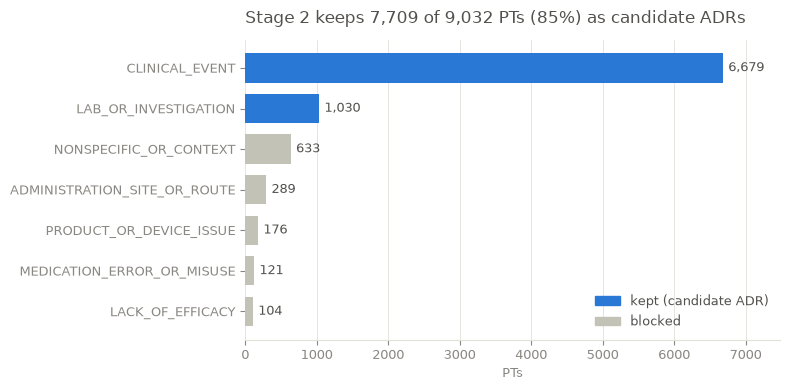

In [32]:
# (3) distribution across the 7 categories
current = set(pd.read_csv(config.UNIQUE_PTS_CSV).pt.astype(str))
types   = pt_types[pt_types.pt.astype(str).isin(current)]

counts  = types.pt_type.value_counts().sort_values()
is_kept = types.groupby("pt_type")["keep"].first()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(counts.index, counts.values,
               color=[BLUE if is_kept[c] else GREY for c in counts.index], height=0.72)

for b, v in zip(bars, counts.values):
    ax.annotate(f"{v:,}", xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", va="center",
                fontsize=9, color=INK)

kept, total = int(types.keep.sum()), len(types)
ax.set_title(f"Stage 2 keeps {kept:,} of {total:,} PTs ({kept/total:.0%}) as candidate ADRs",
             fontsize=12, color=INK, loc="left", pad=12)
ax.set_xlabel("PTs", fontsize=9, color=MUTED)
ax.set_xlim(0, counts.max() * 1.12)
ax.grid(axis="x", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=GREY)]
ax.legend(handles, ["kept (candidate ADR)", "blocked"], frameon=False,
          fontsize=9, loc="lower right", labelcolor=INK)
fig.tight_layout()
plt.show()

---
## 5. Stage 3 — Label comparison: is it already known?

### 5.1 Where the ground truth lives — and why the *brand* matters

A drug's **FDA label** (the SPL document) is the regulatory statement of what the drug is known to do. We fetch it from the **openFDA `drug/label` endpoint** and give the model the ADR-related sections: `indications_and_usage` · `boxed_warning` · `adverse_reactions` · `warnings_and_cautions`, and so on.

But the signal is computed per **active ingredient** (Stage 0), while the **label is per product** — and in the pilot analysis I found that labels differ considerably by **route and form**, and by **manufacturer**.

Each drug is therefore pinned to **one product** for this analysis: I searched on the active ingredient *and* an exact brand name, and took the most recent revision (`effective_time` descending). The **100 active ingredients** were randomly sampled from those with **20–50 significant PTs**, and each **brand name was chosen by hand** from that drug's registered brand list.

### 5.2 The classification: hierarchical, one status per AE

The model assigns each candidate AE exactly one status, in strict order:

1. **`disease_related`** — the AE is the drug's *indication*, the underlying disease, or that disease progressing → confounding by indication, not a reaction.
2. **`already_labeled`** — the label describes the AE as something the drug **can cause**, in *any* section.
3. **`novel`** — everything else. A potential **unlabeled** ADR.

### 5.3 Processing and outputs

`step3_compare_to_label.py` reads `signals.csv` and compares each drug's AEs against its label:

1. **Filter.** Keep only the PTs Stage 2 marked `keep` (`pt_types.csv`).
2. **Fetch.** `fetch_label(drug, brand)` pulls the most recent SPL for the pinned brand and extracts the ADR-related sections.
3. **Classify.** A drug's AEs go to `gpt-4.1` in one batch with the full label text; each returns one status and a one-sentence reason.

It writes one table:

- **`adr_results.csv`** — `prod_ai, pt, n_reports, EBGM, QUANT_05, status, reasoning` + the four provenance columns. The **validation set**: novel candidates *and* the known ADRs that serve as Stage 4's positive controls.


In [ ]:
# (1) Prompt
DRUG, BRAND = "FEBUXOSTAT", "ULORIC"        # exact registered string, uppercase

sig   = s3.load_signals(use_blocklist=True, drugs=[DRUG])
rows  = [{k: r[k] for k in ("prod_ai", "pt", "n_reports", "EBGM", "QUANT_05")}
         for _, r in sig.iterrows()]
label = openfda.fetch_label(DRUG, BRAND)
user  = s3.build_user_prompt(DRUG, label, rows)

print(f"{len(rows)} candidate AEs | label: {label['brand_name']} "
      f"| revision {label['effective_time']}\n")
print("=" * 78, "\nSYSTEM PROMPT\n", "=" * 78, sep="")
print(s3._SYSTEM)
print("\n" + "=" * 78, f"\nUSER PROMPT  ({len(user):,} chars)\n", "=" * 78, sep="")
print(user)          # full prompt, no truncation

blocklist: kept 153242/177823 signals (7709 clinical PTs)
44 candidate AEs | label: ['ULORIC'] | revision 20251224

SYSTEM PROMPT
You are a senior pharmacovigilance expert comparing candidate PTs for one drug against that drug's official FDA label.

Definitions:
- Adverse Drug Reaction (ADR): a noxious and unintended response for which a causal relationship with the medicinal product is at least a reasonable possibility.
- MedDRA Preferred Term (PT): one coded medical concept recorded in a FAERS report.

Background:
The label text is provided as reference material and may include any of the drug's sections -- indications, boxed warning, adverse reactions (narrative text and incidence tables), warnings, precautions, and contraindications. Treat the ENTIRE label as the source of truth; do not limit your search to any single section.

Classification rules:
For each candidate PT, make a hierarchical decision and assign exactly ONE status:
1. If the PT is really the drug's INDICATION, the u

In [ ]:
# (2) how Stage 3 classified febuxostat
feb = pd.DataFrame(s3.classify_drug(DRUG, rows, batch_size=50, brand=BRAND))

print(f"label: {feb.label_brand.iloc[0]} | {feb.label_manufacturer.iloc[0]} "
      f"| revision {feb.label_effective_time.iloc[0]}\n")
print(feb.status.value_counts().to_string(), "\n")

feb[["pt", "n_reports", "EBGM", "status", "reasoning"]].sort_values("EBGM", ascending=False)


label: ULORIC | Takeda Pharmaceuticals America, Inc. | revision 20251224

status
NOVEL              25
ALREADY_LABELED    17
DISEASE_RELATED     2 



,pt,n_reports,EBGM,status,reasoning
0,Cerebral artery thrombosis,10,745.97,NOVEL,Not mentioned in the label as an adverse react...
1,Gouty arthritis,8,397.84,DISEASE_RELATED,Gout and its manifestations are the indication...
2,Enanthema,7,397.74,NOVEL,Not described in the label as an adverse react...
3,Cerebellar infarction,10,267.65,NOVEL,Not mentioned in the label as an adverse react...
4,Superinfection bacterial,10,266.47,NOVEL,Not described in the label as an adverse react...
5,Dyslipidaemia,14,104.93,ALREADY_LABELED,Hyperlipidemia and hypercholesterolemia are li...
6,Gastric perforation,8,83.68,NOVEL,Not mentioned in the label as an adverse react...
7,Cardiovascular insufficiency,5,58.41,NOVEL,Not specifically described in the label as an ...
8,Generalised bullous fixed drug eruption,5,46.38,NOVEL,Not specifically mentioned in the label as an ...
9,Hyperlipidaemia,12,43.01,ALREADY_LABELED,Listed as an adverse reaction in the label.


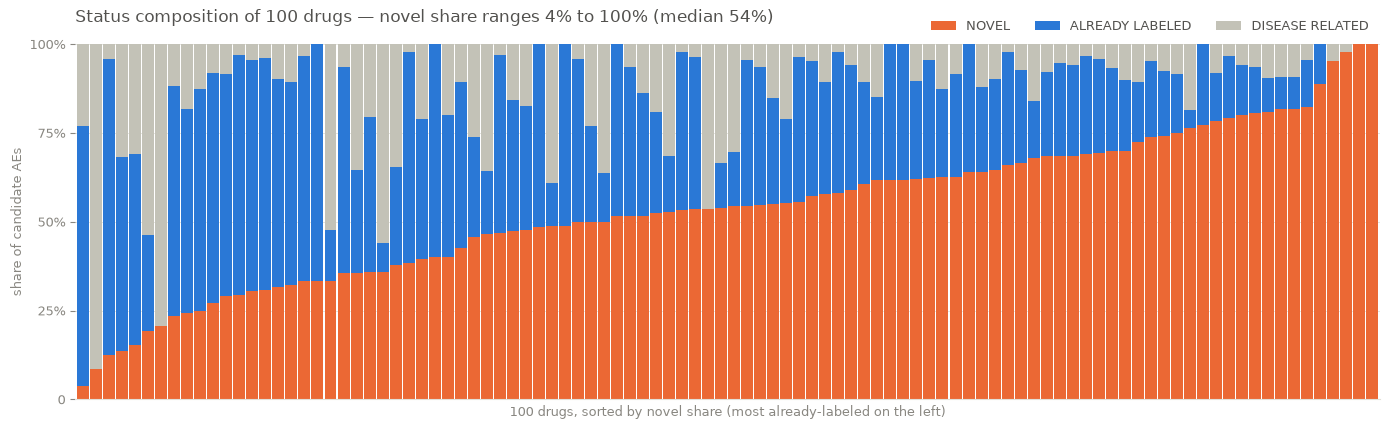

In [34]:
# (3) Stacked bar plot
prop = adr_results.groupby(["prod_ai", "status"]).size().unstack(fill_value=0)
for c in STATUS_ORDER:
    if c not in prop:
        prop[c] = 0
prop = prop[STATUS_ORDER]
prop = prop.div(prop.sum(axis=1), axis=0).sort_values("NOVEL")   # left = most already_labeled

fig, ax = plt.subplots(figsize=(14, 4.4))
x, bottom = np.arange(len(prop)), np.zeros(len(prop))
for c in STATUS_ORDER:
    ax.bar(x, prop[c], bottom=bottom, width=0.92, color=STATUS_COLORS[c],
           label=c.replace("_", " "), linewidth=0)
    bottom += prop[c].values

nov = prop["NOVEL"]
ax.set_title(f"Status composition of {len(prop)} drugs — novel share ranges "
             f"{nov.min():.0%} to {nov.max():.0%} (median {nov.median():.0%})",
             fontsize=12, color=INK, loc="left", pad=16)
ax.set_xlabel(f"{len(prop)} drugs, sorted by novel share (most already-labeled on the left)",
              fontsize=9, color=MUTED)
ax.set_ylabel("share of candidate AEs", fontsize=9, color=MUTED)
ax.set_xlim(-0.6, len(prop) - 0.4)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([0, .25, .5, .75, 1])
ax.set_yticklabels(["0", "25%", "50%", "75%", "100%"])
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)

ax.legend(frameon=False, ncols=3, fontsize=9, labelcolor=INK,
          loc="lower right", bbox_to_anchor=(1, 1.0))     # right of the title, not on top of it
fig.tight_layout()
plt.show()

---
## 6. Stage 4 — Scoring: which novel signal first?

### 6.1 Why EB05 alone is not enough for priority order

Stage 3 leaves too many novel candidates per drug, and disproportionality alone may not be enough to rank them. A **high-EB05** event can be clinically trivial. A **moderate-EB05** event can be fatal, biologically coherent with what the drug already does, and already described in a case report — and that is the one a reviewer must check first. FAERS reports are also **confounded**: a pair whose reports each carry several other suspect drugs is far weaker evidence than one whose reports carry none.

Priority is therefore necessary and a *multi-axis* question.

### 6.2 The five components

Each is normalized to **[0, 1] within a drug** (higher = more worth attention), then combined by an equally weighted sum:

| Component | Definition | Rationale |
|---|---|---|
| **`dispro`** | `log(EB05)` | the statistical signal |
| **`literature`** | max cosine(drug→PT, **cited papers**) | is there already a published case report or literature? |
| **`severity`** | max cosine(PT, **death anchors**) | a fatal event deserves more attention than a trivial one |
| **`plausibility`** | max cosine(PT, the drug's **labeled PTs + indication**) | biological coherence — and note it reuses Stage 3's `already_labeled` output as the definition of "what this drug is known to do" |
| **`low_confounding`** | `1 − log1p(median_suspects)` | fewer suspect drugs on the reports = cleaner attribution |

The three axes (literature, severity, and plausibility) are cosine similarities in the embedding space (`text-embedding-3-large`). For example:

- **`literature`** — the cosine similarity between the embedding of *"The adverse reaction of {drug} is {pt}"* and the embedding of each reference title, taking the maximum.
- **`severity`** — the cosine similarity between the PT and each of the severity anchors (e.g. death, fatal outcome, life-threatening event), taking the maximum.

**Ranking is PER DRUG.** Each component is min–max normalized within a drug and summed, giving a score between 0 and 1 — so scores are **not comparable across drugs**. The question answered is *"for THIS drug, what should I look at first?"*

### 6.3 Validation: labeled ADRs as positive controls

There is no ground-truth list of true novel ADRs. So I use the control we already have:

> Stage 4 scores **every** PT, including the `already_labeled` ones. Those are known, real ADRs — assuming the model categorized them correctly. If the score is meaningful, they must cluster near the top of each drug's ranking.

I report **lift**:

`lift@10 = precision@10 / random_precision`, where `precision@10` = labeled ADRs in the top 10 / 10, and `random_precision` = total labeled / total PTs.

**`lift > 1` means the scoring beats chance.**

### 6.4 Processing and outputs

`step4_score_pts.py` reads `adr_results.csv` and scores every AE:

1. **Embed.** PTs, the drug's labeled PTs + indication, the death anchors, and the pair's cited papers → `text-embedding-3-large`.
2. **Score.** Compute the five components and min–max normalize each *within* the drug.
3. **Combine.** Weighted sum → `final_score`; rank the PTs by `final_score` within each drug.

It writes one table:

- **`scored_adrs.csv`** — one row per (drug, PT): the five components, `final_score`, `rank`, `percentile`, plus everything carried from `adr_results.csv`.


In [35]:
# (1) FEBUXOSTAT, scored
# `feb` is the DataFrame from the Stage 3 cell (needs `pt` + `status`)
scored_feb, _ = s4.score_drug(feb, DRUG, brand_name=BRAND)

cols = ["rank", "pt", "status", "final_score",
        "dispro", "literature", "severity", "plausibility", "low_confounding"]
scored_feb[cols].round(3)

,rank,pt,status,final_score,dispro,literature,severity,plausibility,low_confounding
0,1,Stevens-Johnson syndrome,ALREADY_LABELED,0.734,0.317,1.000,0.962,0.390,1.000
1,2,Drug-induced liver injury,ALREADY_LABELED,0.704,0.152,0.846,0.870,0.652,1.000
2,3,Gastric perforation,NOVEL,0.644,0.392,0.929,0.900,0.000,1.000
3,4,Hyperlipidaemia,ALREADY_LABELED,0.637,0.388,0.000,0.798,1.000,1.000
4,5,Drug reaction with eosinophilia and systemic s...,ALREADY_LABELED,0.635,0.230,0.632,0.894,0.420,1.000
5,6,Hepatic function abnormal,ALREADY_LABELED,0.606,0.000,0.854,0.649,0.527,1.000
6,7,Rhabdomyolysis,ALREADY_LABELED,0.599,0.214,0.861,0.837,0.324,0.762
7,8,Drug eruption,NOVEL,0.595,0.253,0.832,0.804,0.492,0.593
8,9,Cardiovascular insufficiency,NOVEL,0.594,0.247,0.430,0.977,0.317,1.000
9,10,Liver injury,ALREADY_LABELED,0.552,0.108,0.000,1.000,0.652,1.000


In [36]:
# (2) lift@10: five-component score vs EB05 alone
K = 10

def lift_at_k(g: pd.DataFrame, by: str, k: int = K) -> float:
    """precision@k / random_precision, ranking this drug's PTs by `by` (desc)."""
    is_lab = (g.sort_values(by, ascending=False)["status"] == "ALREADY_LABELED").to_numpy()
    base = is_lab.mean()                       # random_precision = labeled / total
    return (is_lab[:k].sum() / k) / base

scored = pd.read_csv(config.SCORED_ADRS_CSV)

# keep only novel + already_labeled; drop drugs that cannot support the metric
d = scored[scored.status.isin(["NOVEL", "ALREADY_LABELED"])]
ok = d.groupby("prod_ai").filter(
    lambda g: len(g) >= K and (g.status == "ALREADY_LABELED").any()
)

lift = (ok.groupby("prod_ai")
          .apply(lambda g: pd.Series({
              "n_pts":      len(g),
              "n_labeled":  int((g.status == "ALREADY_LABELED").sum()),
              "lift_score": lift_at_k(g, "final_score"),
              "lift_eb05":  lift_at_k(g, "QUANT_05"),
          }), include_groups=False)
          .reset_index())

dropped = d.prod_ai.nunique() - len(lift)
print(f"drugs evaluated: {len(lift)}  (dropped {dropped}: <{K} PTs or no labeled AE)\n")
print(lift[["lift_score", "lift_eb05"]].describe().loc[["50%", "mean"]].round(2).to_string())
print(f"\nlift > 1 -- score: {(lift.lift_score > 1).mean():.0%} of drugs"
      f"  |  EB05: {(lift.lift_eb05 > 1).mean():.0%} of drugs")


drugs evaluated: 93  (dropped 7: <10 PTs or no labeled AE)

      lift_score  lift_eb05
50%         1.32       1.00
mean        1.42       0.95

lift > 1 -- score: 78% of drugs  |  EB05: 46% of drugs


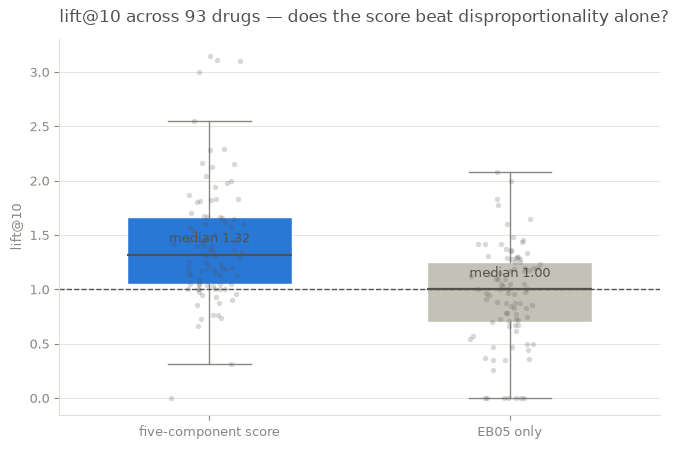

In [ ]:
# (3) figure
data = [lift.lift_score.values, lift.lift_eb05.values]

fig, ax = plt.subplots(figsize=(6.8, 4.6))
bp = ax.boxplot(data, widths=0.55, patch_artist=True, showfliers=False,
                medianprops=dict(color=INK, linewidth=1.6),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                boxprops=dict(edgecolor="white", linewidth=1))
for patch, c in zip(bp["boxes"], [BLUE, GREY]):
    patch.set_facecolor(c)

rng = np.random.default_rng(0)
for i, s in enumerate(data, start=1):
    ax.scatter(rng.normal(i, 0.055, len(s)), s, s=15, color=INK,
               alpha=0.22, zorder=3, linewidths=0)

ax.axhline(1, color=INK, linestyle="--", linewidth=1, zorder=2)
ax.annotate("lift = 1 (chance)", xy=(2.55, 1), xytext=(0, 4), textcoords="offset points",
            ha="right", fontsize=9, color=MUTED)

for i, s in enumerate(data, start=1):
    ax.annotate(f"median {np.median(s):.2f}", xy=(i, np.median(s)), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9, color=INK)

ax.set_title(f"lift@{K} across {len(lift)} drugs — does the score beat disproportionality alone?",
             fontsize=12, color=INK, loc="left", pad=12)
ax.set_xticks([1, 2])
ax.set_xticklabels(["five-component score", "EB05 only"], fontsize=10, color=INK)
ax.set_ylabel(f"lift@{K}", fontsize=9, color=MUTED)
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)
fig.tight_layout()
plt.show()


---
## 7. Discussion

### 7.1 What was built

An end-to-end pipeline that turns raw FAERS reports into a **per-drug, prioritized shortlist of potentially unlabeled ADRs**:

> **FAERS reports** → *(Stage 1, statistics)* **disproportionate pairs** → *(Stage 2, LLM)* **genuine clinical events** → *(Stage 3, LLM + FDA label)* **not already known** → *(Stage 4, Scoring)* **ranked by severity, biology, literature, and confounding**

**The validation argument:** known ADRs, scored with no knowledge that they are known (unless PTs in labels are dependent each other), rise to the top of each drug's ranking (lift > 1), and the five-component score outperforms EB05 alone. The novel events that rank *alongside them* are the ones worth a reviewer's time.

### 7.2 Limitations & future work

**FAERS reports.** We restricted the analysis to reports listing no more than 10 suspect drugs, which alleviates the confounding effect but is a heuristic and does not remove it entirely. It would also be preferable to incorporate more product information — the route of administration, for example — into the statistical model where available.

**EBGM.** The estimation does not appear to be robust, particularly when fitting the prior hyperparameters on λ. However, the log(RRR) versus EBGM plot shows that the model substantially shrinks estimates toward the null, particularly for drug–event pairs with fewer reports.

**The LLM stages are unevaluated.** While the prompt was engineered to have the consistent and correct result based on my knowledge, there is no robust evaluation of Stages 2 and 3 — for example, whether the `already_labeled` PTs really do appear in the label. An evaluation of the LLM output is necessary.

**The score is untuned.** Equal weights, never calibrated; they could instead be learned from the data. Also, the literature, plausibility, and severity components are also computed only from information already in the FAERS reports, by simple cosine similarity in the embedding space. These could be improved with external data and further LLM use — for example, an automated PubMed search for literature linking a drug to an ADR.
